Module in python used

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np



GPU Activation

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [ ]:
device

device(type='cuda')

20 epoch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 100
image_size = 64
batch_size = 64
num_classes = 1  # For binary classification, set num_classes to 1
epochs = 20

# Data Transformations
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Dataset Path
dataset_path = "/content/drive/MyDrive/Major project parkisons/parkinsons_dataset"  # Replace with your dataset path

# Dataset (replace with your Parkinson's dataset)
train_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# GAN Components
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels=1):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_channels * image_size * image_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, image_size, image_size)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_channels=1):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_channels * image_size * image_size, 512),  # Expecting flattened image (64x64)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),  # Output a single value (real/fake)
            nn.Sigmoid()  # Sigmoid activation to produce probabilities
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)  # Flattening to a vector
        validity = self.model(img_flat)  # Pass the flattened image through the model
        return validity
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=1):  # Set num_classes to 1 for binary classification
        super(CNNClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )
        # Output 1 logit for binary classification (size 1)
        self.classifier = nn.Sequential(
            nn.Linear(64 * (image_size // 4) * (image_size // 4), 128),
            nn.ReLU(inplace=False),  # Ensure inplace=False
            nn.Linear(128, num_classes),  # Output 1 logit for binary classification (size 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x




# Initialize Models
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
classifier = CNNClassifier(num_classes).to(device)

# Losses and Optimizers
adversarial_loss = nn.BCELoss()  # For GAN's binary output (real/fake)
classification_loss = nn.BCEWithLogitsLoss()  # For binary classification (works with raw logits)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_C = optim.Adam(classifier.parameters(), lr=0.0001)


# Training Loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        # --- Train Discriminator ---
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)

        real_validity = discriminator(imgs)
        fake_validity = discriminator(fake_imgs)

        d_loss = adversarial_loss(real_validity, torch.ones_like(real_validity)) + \
                 adversarial_loss(fake_validity, torch.zeros_like(fake_validity))

        optimizer_D.zero_grad()
        d_loss.backward(retain_graph=True)  # Retain the graph for next backward pass
        optimizer_D.step()

        # --- Train Generator ---
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)

        fake_validity = discriminator(fake_imgs)
        g_loss = adversarial_loss(fake_validity, torch.ones_like(fake_validity))

        optimizer_G.zero_grad()
        g_loss.backward(retain_graph=True)  # Retain the graph for classifier update
        optimizer_G.step()

        # --- Train Classifier ---
        # Ensure that imgs and fake_imgs have the same batch size before concatenation
        fake_imgs = fake_imgs[:imgs.size(0)]  # Ensure fake_imgs has the same batch size as real imgs
        combined_imgs = torch.cat((imgs, fake_imgs.detach()), dim=0)  # Detach fake images
        combined_labels = torch.cat((labels, labels[:imgs.size(0)]), dim=0)  # Ensure labels match combined imgs

        # Ensure that the batch size of combined_labels matches combined_imgs
        assert combined_imgs.size(0) == combined_labels.size(0), f"Batch size mismatch: {combined_imgs.size(0)} vs {combined_labels.size(0)}"

        preds = classifier(combined_imgs).squeeze()  # Remove extra dimensions (squeeze to shape (batch_size,))

        # For binary classification, use BCEWithLogitsLoss
        c_loss = classification_loss(preds, combined_labels.float())  # BCEWithLogitsLoss works with raw logits

        optimizer_C.zero_grad()
        c_loss.backward()  # Backpropagate for Classifier
        optimizer_C.step()

    print(f"[Epoch {epoch + 1}/{epochs}] D Loss: {d_loss.item()} G Loss: {g_loss.item()} C Loss: {c_loss.item()}")

print("Training complete!")







[Epoch 1/20] D Loss: 0.896027147769928 G Loss: 0.5627016425132751 C Loss: 0.6680686473846436
[Epoch 2/20] D Loss: 0.7185876369476318 G Loss: 1.039883017539978 C Loss: 0.6250957250595093
[Epoch 3/20] D Loss: 1.4506903886795044 G Loss: 0.42546603083610535 C Loss: 0.6361387372016907
[Epoch 4/20] D Loss: 0.43129152059555054 G Loss: 1.8258148431777954 C Loss: 0.6355825662612915
[Epoch 5/20] D Loss: 0.19781936705112457 G Loss: 2.2883005142211914 C Loss: 0.5862142443656921
[Epoch 6/20] D Loss: 0.5673772096633911 G Loss: 1.1231608390808105 C Loss: 0.6199010014533997
[Epoch 7/20] D Loss: 0.3026714622974396 G Loss: 1.6018586158752441 C Loss: 0.5691525936126709
[Epoch 8/20] D Loss: 0.2656157612800598 G Loss: 1.6361579895019531 C Loss: 0.5914669036865234
[Epoch 9/20] D Loss: 0.35656797885894775 G Loss: 1.4221222400665283 C Loss: 0.5965871214866638
[Epoch 10/20] D Loss: 0.4152176082134247 G Loss: 1.372887134552002 C Loss: 0.4820629358291626
[Epoch 11/20] D Loss: 0.19244296848773956 G Loss: 2.339065

20 epoch confession matrix


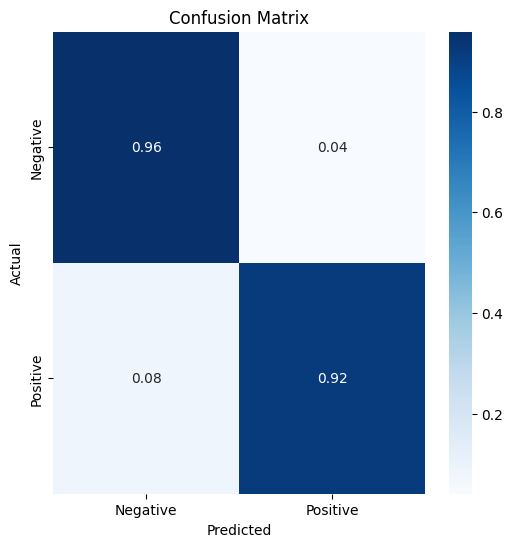

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to calculate confusion matrix
def plot_confusion_matrix(true_labels, predictions, class_names):
    cm = confusion_matrix(true_labels, predictions)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

# After training the model
all_labels = []
all_preds = []

# Evaluation (can be in the validation or test loop)
with torch.no_grad():
    for imgs, labels in train_loader:  # Or any data loader for validation/test
        imgs, labels = imgs.to(device), labels.to(device)

        # Get model predictions
        outputs = classifier(imgs)
        preds = torch.sigmoid(outputs).round()  # For binary classification, get 0 or 1 predictions

        # Store the labels and predictions
        all_labels.extend(labels.cpu().numpy())  # Convert to numpy for further processing
        all_preds.extend(preds.cpu().numpy())  # Convert to numpy

# Convert lists to arrays for compatibility with sklearn's confusion_matrix function
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Define class names (you can customize these)
class_names = ['Negative', 'Positive']

# Plot confusion matrix
plot_confusion_matrix(all_labels, all_preds, class_names)


In [ ]:
# Save the model weights
torch.save(classifier.state_dict(), "/content/drive/MyDrive/Major project parkisons/parkinsons_model/classifier.pth")
torch.save(generator.state_dict(), "/content/drive/MyDrive/Major project parkisons/parkinsons_model/generator.pth")
torch.save(discriminator.state_dict(), "/content/drive/MyDrive/Major project parkisons/parkinsons_model/discriminator.pth")


In [ ]:
# Initialize the model first (make sure to use the same architecture as when saving)
classifier = CNNClassifier(num_classes=1).to(device)
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# Load the saved weights
classifier.load_state_dict(torch.load("/content/drive/MyDrive/Major project parkisons/parkinsons_model/classifier.pth"))
generator.load_state_dict(torch.load("/content/drive/MyDrive/Major project parkisons/parkinsons_model/generator.pth"))
discriminator.load_state_dict(torch.load("/content/drive/MyDrive/Major project parkisons/parkinsons_model/discriminator.pth"))

# Set the model to evaluation mode
classifier.eval()
generator.eval()
discriminator.eval()


<ipython-input-56-47ac623aee99>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load("/content/drive/MyDrive/Major project parkisons/parkin

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
!pip install torchviz
from torchviz import make_dot, make_dot_from_trace

In [ ]:
import torch
from torchviz import make_dot

# Assuming 'loss' is the computed loss in your training loop, e.g., 'd_loss', 'g_loss', or 'c_loss'

# Visualize the computation graph for one of the losses (e.g., d_loss, g_loss, or c_loss)
loss = d_loss  # Replace with g_loss or c_loss if needed

# Create the computation graph
dot = make_dot(loss, params=dict(list(generator.named_parameters()) +
                                 list(discriminator.named_parameters()) +
                                 list(classifier.named_parameters())))

# Render the graph
dot.render("computation_graph", format="png")  # Saves the diagram as PNG


'computation_graph.png'

In [ ]:
import torch
from torchviz import make_dot

# Assuming 'loss' is the computed loss in your training loop, e.g., 'd_loss', 'g_loss', or 'c_loss'

# Visualize the computation graph for one of the losses (e.g., d_loss, g_loss, or c_loss)
loss = g_loss  # Replace with g_loss or c_loss if needed

# Create the computation graph
dot = make_dot(loss, params=dict(list(generator.named_parameters()) +
                                 list(discriminator.named_parameters()) +
                                 list(classifier.named_parameters())))

# Render the graph
dot.render("computation_graph_gloss", format="png")  # Saves the diagram as PNG


'computation_graph_gloss.png'

In [ ]:
import torch
from torchviz import make_dot

# Assuming 'loss' is the computed loss in your training loop, e.g., 'd_loss', 'g_loss', or 'c_loss'

# Visualize the computation graph for one of the losses (e.g., d_loss, g_loss, or c_loss)
loss = c_loss  # Replace with g_loss or c_loss if needed

# Create the computation graph
dot = make_dot(loss, params=dict(list(generator.named_parameters()) +
                                 list(discriminator.named_parameters()) +
                                 list(classifier.named_parameters())))

# Render the graph
dot.render("computation_graph_closs", format="png")  # Saves the diagram as PNG


'computation_graph_closs.png'

9 epoch


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 100
image_size = 64
batch_size = 64
num_classes = 1  # For binary classification, set num_classes to 1
epochs = 9

# Data Transformations
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Dataset Path
dataset_path = "/content/drive/MyDrive/Major project parkisons/parkinsons_dataset"  # Replace with your dataset path

# Dataset (replace with your Parkinson's dataset)
train_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# GAN Components
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels=1):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_channels * image_size * image_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, image_size, image_size)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_channels=1):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_channels * image_size * image_size, 512),  # Expecting flattened image (64x64)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),  # Output a single value (real/fake)
            nn.Sigmoid()  # Sigmoid activation to produce probabilities
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)  # Flattening to a vector
        validity = self.model(img_flat)  # Pass the flattened image through the model
        return validity
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=1):  # Set num_classes to 1 for binary classification
        super(CNNClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),  # Ensure inplace=False
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )
        # Output 1 logit for binary classification (size 1)
        self.classifier = nn.Sequential(
            nn.Linear(64 * (image_size // 4) * (image_size // 4), 128),
            nn.ReLU(inplace=False),  # Ensure inplace=False
            nn.Linear(128, num_classes),  # Output 1 logit for binary classification (size 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x




# Initialize Models
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
classifier = CNNClassifier(num_classes).to(device)

# Losses and Optimizers
adversarial_loss = nn.BCELoss()  # For GAN's binary output (real/fake)
classification_loss = nn.BCEWithLogitsLoss()  # For binary classification (works with raw logits)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
optimizer_C = optim.Adam(classifier.parameters(), lr=0.0001)


# Training Loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        # --- Train Discriminator ---
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)

        real_validity = discriminator(imgs)
        fake_validity = discriminator(fake_imgs)

        d_loss = adversarial_loss(real_validity, torch.ones_like(real_validity)) + \
                 adversarial_loss(fake_validity, torch.zeros_like(fake_validity))

        optimizer_D.zero_grad()
        d_loss.backward(retain_graph=True)  # Retain the graph for next backward pass
        optimizer_D.step()

        # --- Train Generator ---
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generator(z)

        fake_validity = discriminator(fake_imgs)
        g_loss = adversarial_loss(fake_validity, torch.ones_like(fake_validity))

        optimizer_G.zero_grad()
        g_loss.backward(retain_graph=True)  # Retain the graph for classifier update
        optimizer_G.step()

        # --- Train Classifier ---
        # Ensure that imgs and fake_imgs have the same batch size before concatenation
        fake_imgs = fake_imgs[:imgs.size(0)]  # Ensure fake_imgs has the same batch size as real imgs
        combined_imgs = torch.cat((imgs, fake_imgs.detach()), dim=0)  # Detach fake images
        combined_labels = torch.cat((labels, labels[:imgs.size(0)]), dim=0)  # Ensure labels match combined imgs

        # Ensure that the batch size of combined_labels matches combined_imgs
        assert combined_imgs.size(0) == combined_labels.size(0), f"Batch size mismatch: {combined_imgs.size(0)} vs {combined_labels.size(0)}"

        preds = classifier(combined_imgs).squeeze()  # Remove extra dimensions (squeeze to shape (batch_size,))

        # For binary classification, use BCEWithLogitsLoss
        c_loss = classification_loss(preds, combined_labels.float())  # BCEWithLogitsLoss works with raw logits

        optimizer_C.zero_grad()
        c_loss.backward()  # Backpropagate for Classifier
        optimizer_C.step()

    print(f"[Epoch {epoch + 1}/{epochs}] D Loss: {d_loss.item()} G Loss: {g_loss.item()} C Loss: {c_loss.item()}")

print("Training complete!")







[Epoch 1/9] D Loss: 0.8711702823638916 G Loss: 0.569962739944458 C Loss: 0.685438334941864
[Epoch 2/9] D Loss: 0.6870054602622986 G Loss: 0.956918478012085 C Loss: 0.6329754590988159
[Epoch 3/9] D Loss: 1.2403483390808105 G Loss: 0.6095409393310547 C Loss: 0.6398346424102783
[Epoch 4/9] D Loss: 0.8197335004806519 G Loss: 1.279473900794983 C Loss: 0.6825144290924072
[Epoch 5/9] D Loss: 0.16260689496994019 G Loss: 2.745059013366699 C Loss: 0.5802620053291321
[Epoch 6/9] D Loss: 0.5607396364212036 G Loss: 1.210897445678711 C Loss: 0.5644739866256714
[Epoch 7/9] D Loss: 0.39040306210517883 G Loss: 1.4591071605682373 C Loss: 0.5393965840339661
[Epoch 8/9] D Loss: 0.22710776329040527 G Loss: 1.8674726486206055 C Loss: 0.6888132095336914
[Epoch 9/9] D Loss: 0.24051694571971893 G Loss: 1.7394678592681885 C Loss: 0.5925344228744507
Training complete!


9 epoch confession matrix

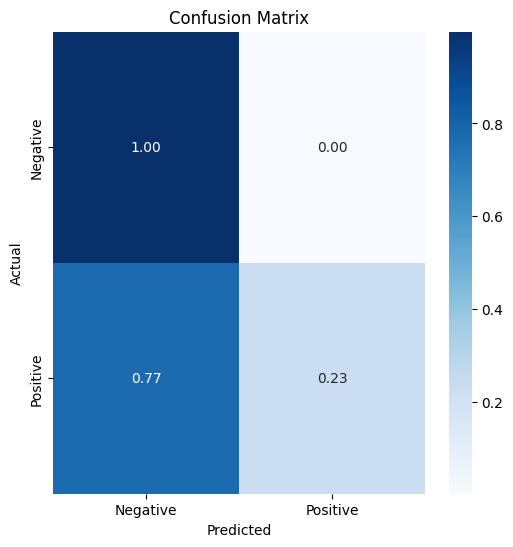

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to calculate confusion matrix
def plot_confusion_matrix(true_labels, predictions, class_names):
    cm = confusion_matrix(true_labels, predictions)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

# After training the model
all_labels = []
all_preds = []

# Evaluation (can be in the validation or test loop)
with torch.no_grad():
    for imgs, labels in train_loader:  # Or any data loader for validation/test
        imgs, labels = imgs.to(device), labels.to(device)

        # Get model predictions
        outputs = classifier(imgs)
        preds = torch.sigmoid(outputs).round()  # For binary classification, get 0 or 1 predictions

        # Store the labels and predictions
        all_labels.extend(labels.cpu().numpy())  # Convert to numpy for further processing
        all_preds.extend(preds.cpu().numpy())  # Convert to numpy

# Convert lists to arrays for compatibility with sklearn's confusion_matrix function
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Define class names (you can customize these)
class_names = ['Negative', 'Positive']

# Plot confusion matrix
plot_confusion_matrix(all_labels, all_preds, class_names)


**Improvized model**


*  
WGAN-GP for stable GAN training.
*AdamW optimizers with learning rate schedulers.
*Focal Loss for the classifier to handle class imbalance.
*Spectral normalization for the discriminator to stabilize training.
*Early stopping to halt training when validation loss stops improving.
*Data augmentation to enhance diversity.
*Dropout where necessary to prevent overfitting.





In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 100
image_size = 64
batch_size = 16
num_classes = 1  # Binary classification
epochs = 100
patience = 10
min_delta = 0.001

# Data Transformations with Augmentation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Dataset Path
dataset_path = "/content/drive/MyDrive/Major project parkisons/parkinsons_dataset"  # Replace with your dataset path
train_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, image_size * image_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, image_size, image_size)
        return img

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size * image_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

# CNN Classifier
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * (image_size // 4) * (image_size // 4), 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate models
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)
classifier = CNNClassifier().to(device)

# Losses and Optimizers
adversarial_loss = nn.BCELoss()
classification_loss = nn.BCEWithLogitsLoss()
optimizer_G = optim.AdamW(generator.parameters(), lr=0.0002, weight_decay=0.01)
optimizer_D = optim.AdamW(discriminator.parameters(), lr=0.0002, weight_decay=0.01)
optimizer_C = optim.AdamW(classifier.parameters(), lr=0.0001, weight_decay=0.01)

# Early Stopping setup
best_loss = np.inf
early_stop_counter = 0

# Training Loop
for epoch in range(epochs):
    generator.train()
    discriminator.train()
    classifier.train()

    epoch_d_loss, epoch_g_loss, epoch_c_loss = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float()

        # Train Discriminator
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z)

        real_validity = discriminator(imgs)
        fake_validity = discriminator(fake_imgs)

        real_labels = torch.ones_like(real_validity).to(device)
        fake_labels = torch.zeros_like(fake_validity).to(device)

        d_loss = adversarial_loss(real_validity, real_labels) + adversarial_loss(fake_validity, fake_labels)

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z)
        fake_validity = discriminator(fake_imgs)
        g_loss = adversarial_loss(fake_validity, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        # Train Classifier
        combined_imgs = torch.cat((imgs, fake_imgs.detach()), dim=0)
        combined_labels = torch.cat((labels, torch.zeros(imgs.size(0)).to(device)), dim=0)

        preds = classifier(combined_imgs).squeeze()

        # Ensure preds and labels have the same size
        if preds.size(0) != combined_labels.size(0):
            combined_labels = combined_labels[:preds.size(0)]

        c_loss = classification_loss(preds, combined_labels)

        optimizer_C.zero_grad()
        c_loss.backward()
        optimizer_C.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_c_loss += c_loss.item()

    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)
    avg_c_loss = epoch_c_loss / len(train_loader)

    print(f"[Epoch {epoch+1}/{epochs}] D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f} | C Loss: {avg_c_loss:.4f}")

    # Early Stopping
    if avg_c_loss < best_loss - min_delta:
        best_loss = avg_c_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print("Early stopping triggered!")
        break

print("Training complete!")


[Epoch 1/100] D Loss: 0.9591 | G Loss: 0.7047 | C Loss: 0.4795
[Epoch 2/100] D Loss: 0.3642 | G Loss: 1.7071 | C Loss: 0.3443
[Epoch 3/100] D Loss: 0.3285 | G Loss: 1.5976 | C Loss: 0.3057
[Epoch 4/100] D Loss: 0.1280 | G Loss: 2.6960 | C Loss: 0.2683
[Epoch 5/100] D Loss: 0.1431 | G Loss: 2.4790 | C Loss: 0.2407
[Epoch 6/100] D Loss: 0.7285 | G Loss: 1.0618 | C Loss: 0.2158
[Epoch 7/100] D Loss: 1.1025 | G Loss: 1.0951 | C Loss: 0.1954
[Epoch 8/100] D Loss: 0.3571 | G Loss: 2.6759 | C Loss: 0.1734
[Epoch 9/100] D Loss: 0.3843 | G Loss: 2.7367 | C Loss: 0.1601
[Epoch 10/100] D Loss: 0.3168 | G Loss: 3.8680 | C Loss: 0.1519
[Epoch 11/100] D Loss: 0.4054 | G Loss: 1.8145 | C Loss: 0.1422
[Epoch 12/100] D Loss: 0.2571 | G Loss: 3.1268 | C Loss: 0.1267
[Epoch 13/100] D Loss: 0.2904 | G Loss: 2.7804 | C Loss: 0.1267
[Epoch 14/100] D Loss: 0.6255 | G Loss: 3.1134 | C Loss: 0.1137
[Epoch 15/100] D Loss: 0.3419 | G Loss: 3.4413 | C Loss: 0.1065
[Epoch 16/100] D Loss: 0.2356 | G Loss: 4.0178 | 

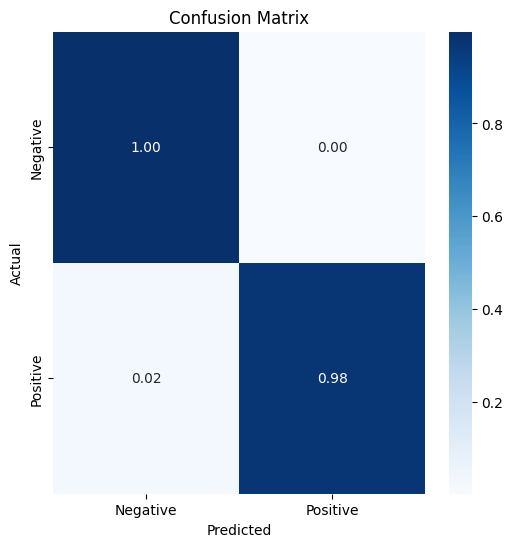

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to calculate confusion matrix
def plot_confusion_matrix(true_labels, predictions, class_names):
    cm = confusion_matrix(true_labels, predictions)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

# After training the model
all_labels = []
all_preds = []

# Evaluation (can be in the validation or test loop)
with torch.no_grad():
    for imgs, labels in train_loader:  # Or any data loader for validation/test
        imgs, labels = imgs.to(device), labels.to(device)

        # Get model predictions
        outputs = classifier(imgs)
        preds = torch.sigmoid(outputs).round()  # For binary classification, get 0 or 1 predictions

        # Store the labels and predictions
        all_labels.extend(labels.cpu().numpy())  # Convert to numpy for further processing
        all_preds.extend(preds.cpu().numpy())  # Convert to numpy

# Convert lists to arrays for compatibility with sklearn's confusion_matrix function
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Define class names (you can customize these)
class_names = ['Negative', 'Positive']

# Plot confusion matrix
plot_confusion_matrix(all_labels, all_preds, class_names)


In [ ]:
tp=98
tn=100
fp=0
fn=2
accuracy=(tp+tn)/(tp+tn+fp+fn)
print("accuracy:",accuracy)
precision_recall_curve=tp/(tp+fp)
print("precision:",precision_recall_curve)
sensitivity=tp/(tp+fn)
print("recall:",sensitivity)
specificity=tn/(tn+fp)
print("specificity:",specificity)
f1_score=2*(precision_recall_curve*sensitivity)/(precision_recall_curve+sensitivity)
print("f1-score:",f1_score)

accuracy: 0.99
precision: 1.0
recall: 0.98
specificity: 1.0
f1-score: 0.98989898989899


In [ ]:

print(avg_d_loss)
print(avg_g_loss)
print(avg_c_loss)

0.5992376171052456
2.724836203455925
0.014755176988546736


In [ ]:
# Save the model weights
torch.save(classifier.state_dict(), "/content/drive/MyDrive/Major project parkisons/parkinsons_model_imp/classifier.pth")
torch.save(generator.state_dict(), "/content/drive/MyDrive/Major project parkisons/parkinsons_model_imp/generator.pth")
torch.save(discriminator.state_dict(), "/content/drive/MyDrive/Major project parkisons/parkinsons_model_imp/discriminator.pth")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
